In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("games-large.csv")

# Preview
df.head()

,id,name,platform,genre,developer,original_release_date
0,26379,Witches,PlayStation 3,Action,Revistronic,12/15/2011
1,26379,Witches,PC,Action,Revistronic,12/15/2011
2,26379,Witches,Xbox 360,Action,Revistronic,12/15/2011
3,31865,Puss in Boots,Mac,Card Game,Magnussoft Deutschland GmbH,11/15/2011
4,30330,Kingdoms of Amalur: Reckoning,PC,Role-Playing,38 Studios,9/15/2011


In [3]:
print(df.info())
print(df.describe())

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 22286 entries, 0 to 22285
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id                     22286 non-null  int64
 1   name                   22286 non-null  str  
 2   platform               22286 non-null  str  
 3   genre                  22286 non-null  str  
 4   developer              22286 non-null  str  
 5   original_release_date  22286 non-null  str  
dtypes: int64(1), str(5)
memory usage: 2.4 MB
None
                 id
count  22286.000000
mean   15126.553935
std     8821.913660
min        3.000000
25%     7445.000000
50%    15379.000000
75%    22099.000000
max    32908.000000


id                       0
name                     0
platform                 0
genre                    0
developer                0
original_release_date    0
dtype: int64

In [5]:
for col in df.columns:
    print(f"'{col}'")

'id'
'name'
'platform'
'genre'
'developer'
'original_release_date'


In [7]:
df[col] = df[col].astype(str)

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = df.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [11]:
print(df.columns)

Index(['id', 'name', 'platform', 'genre', 'developer',
       'original_release_date'],
      dtype='str')


In [13]:
# 1. Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

# 2. Load dataset
data = load_iris()

# 3. Create DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 4. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Check
print(X_train.head())
print(y_train.head())

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
22                4.6               3.6                1.0               0.2
15                5.7               4.4                1.5               0.4
65                6.7               3.1                4.4               1.4
11                4.8               3.4                1.6               0.2
42                4.4               3.2                1.3               0.2
22    0
15    0
65    1
11    0
42    0
dtype: int64


In [14]:
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [15]:
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree MSE:", mse_dt)
print("Decision Tree R2:", r2_dt)

Decision Tree MSE: 0.0
Decision Tree R2: 1.0


In [21]:
# Imports
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create model
rf_model = RandomForestRegressor(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MSE: 0.0013833333333333336
Random Forest R2: 0.9980206677265501


In [22]:
importances = rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

             Feature  Importance
2  petal length (cm)    0.495626
3   petal width (cm)    0.484710
1   sepal width (cm)    0.012416
0  sepal length (cm)    0.007248


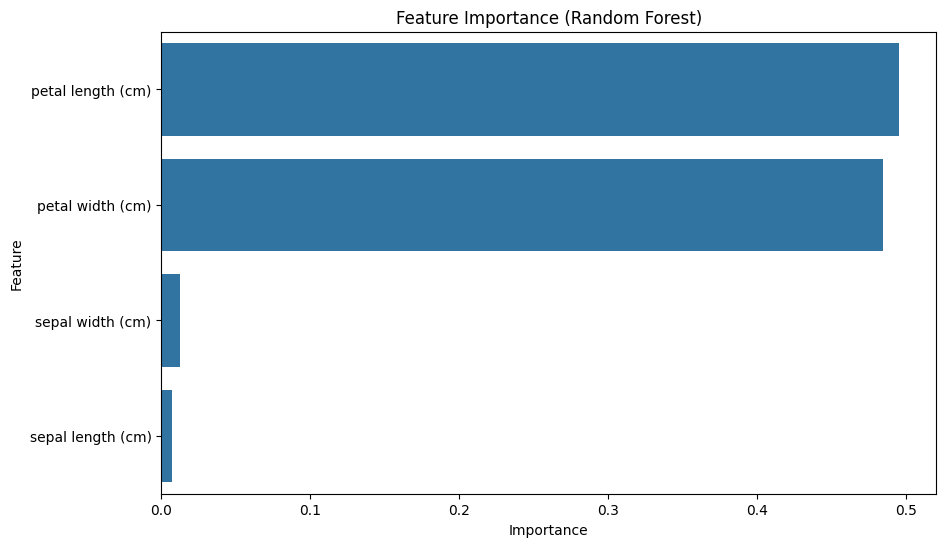

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance (Random Forest)")
plt.show()

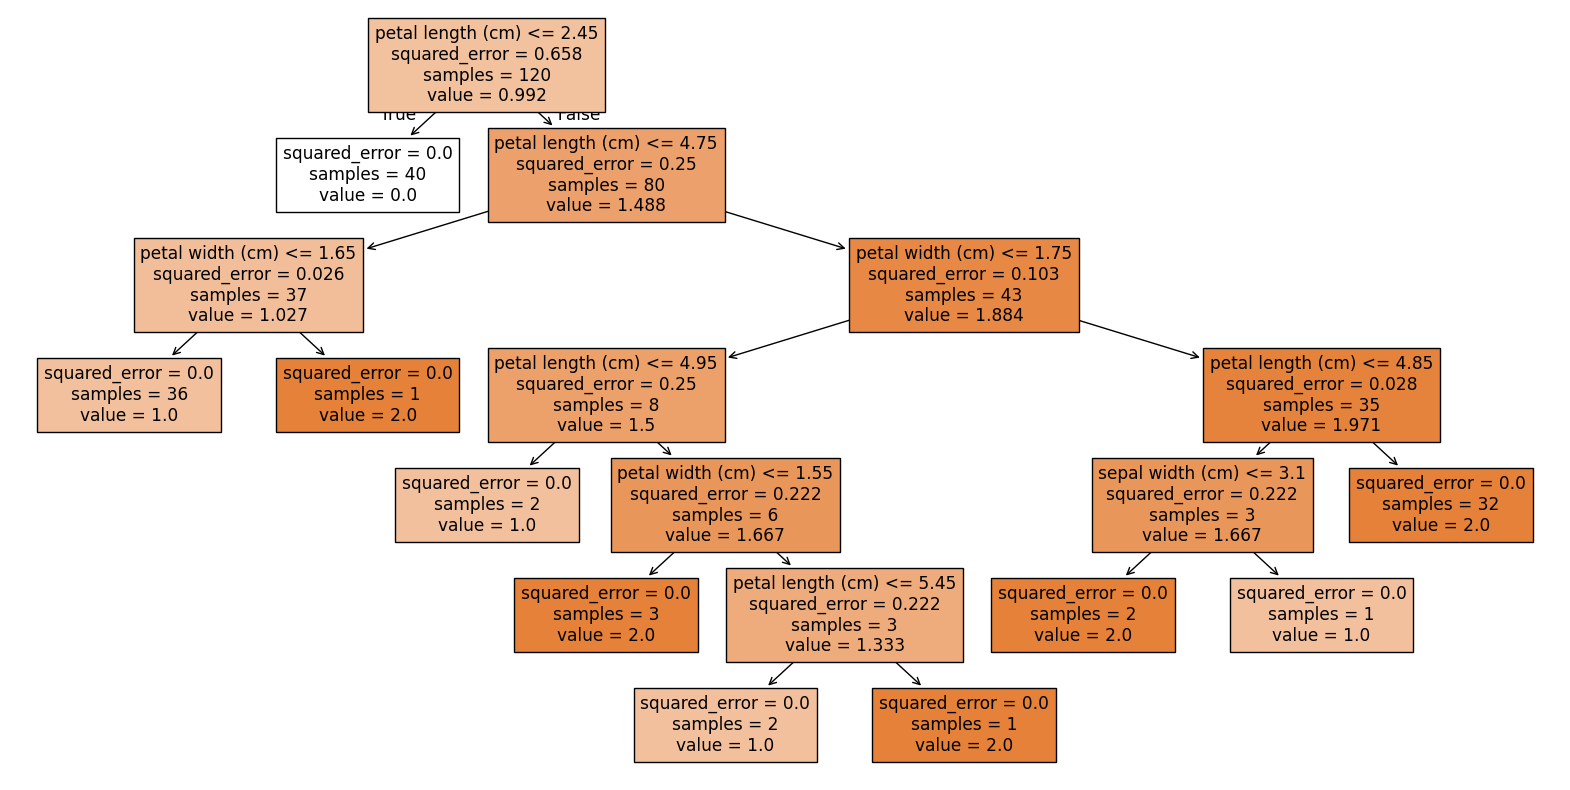

In [24]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, filled=True)
plt.show()